In [15]:
%%writefile boltzmann.cpp
#include <iostream>
#include <cmath>
#include <fstream>
using namespace std;

const double lambda_param = 1e9;
const double a_eq = 0.145;

double Y_EQ(double x) { return a_eq * pow(x, 1.5) * exp(-x); }
double dYdx(double x, double Y) {
    double y_eq = Y_EQ(x);
    return -(lambda_param / (x * x)) * (Y * Y - y_eq * y_eq);
}

int main() {
    double x = 1.0;
    double Y = Y_EQ(x);
    double x_final = 50.0; // Reducimos un poco el rango para mejor visualización
    double h = 0.001;      // Paso más pequeño para mayor precisión

    ofstream file("boltzmann_yield.txt");
    file << "x Y Y_EQ\n";

    while (x <= x_final) {
        file << x << " " << Y << " " << Y_EQ(x) << "\n";
        double k1 = h * dYdx(x, Y);
        double k2 = h * dYdx(x + h/2.0, Y + k1/2.0);
        double k3 = h * dYdx(x + h/2.0, Y + k2/2.0);
        double k4 = h * dYdx(x + h, Y + k3);

        Y += (k1 + 2*k2 + 2*k3 + k4) / 6.0;
        x += h;
    }
    file.close();
    cout << "Datos de Materia Oscura guardados en 'boltzmann_yield.txt'" << endl;
    return 0;
}

Overwriting boltzmann.cpp


In [16]:
!g++ boltzmann.cpp -o boltzmann
!./boltzmann

Datos de Materia Oscura guardados en 'boltzmann_yield.txt'


In [17]:
%%writefile ising.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <ctime>
#include <fstream>
using namespace std;

double simular_ising(int L, double T, double H, int sweeps) {
    int N = L * L;
    vector<int> red(N);
    for (int i = 0; i < N; i++) red[i] = (rand() % 2 == 0) ? 1 : -1;
    double mag_acum = 0.0; int mediciones = 0;
    for (int sweep = 0; sweep < sweeps; sweep++) {
        for (int step = 0; step < N; step++) {
            int idx = rand() % N;
            double delta_E = 2.0 * H * red[idx];
            if (delta_E < 0.0 || ((double)rand()/RAND_MAX) <= exp(-delta_E/T))
                red[idx] *= -1;
        }
        if (sweep > sweeps * 0.2) {
            double mag = 0;
            for (int i : red) mag += i;
            mag_acum += mag / N;
            mediciones++;
        }
    }
    return mag_acum / mediciones;
}

int main() {
    srand(time(NULL));
    ofstream file("ising_magnetizacion.txt");
    for (double H = -30.0; H <= 30.0; H += 3.0) {
        file << H << " " << simular_ising(20, 5.0, H, 500) << " "
             << simular_ising(20, 15.0, H, 500) << " " << simular_ising(20, 20.0, H, 500) << "\n";
    }
    file.close();
    return 0;
}

Overwriting ising.cpp


In [18]:
!g++ ising.cpp -o ising
!./ising

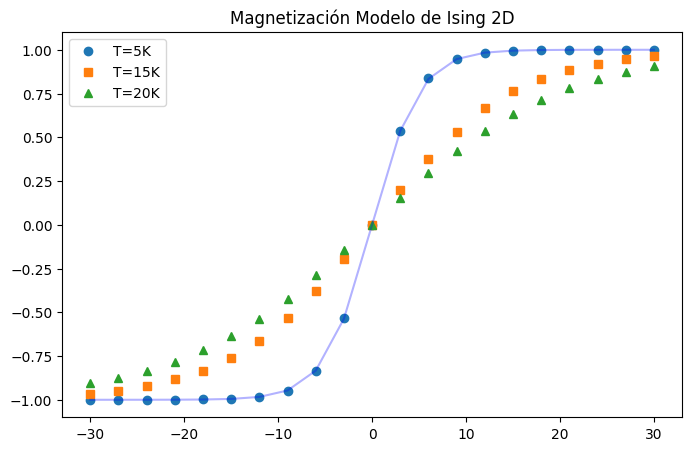

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Graficar Ising
data = np.loadtxt("ising_magnetizacion.txt")
plt.figure(figsize=(8,5))
plt.plot(data[:,0], data[:,1], 'o', label='T=5K')
plt.plot(data[:,0], data[:,2], 's', label='T=15K')
plt.plot(data[:,0], data[:,3], '^', label='T=20K')
plt.plot(data[:,0], np.tanh(data[:,0]/5.0), 'b-', alpha=0.3)
plt.title("Magnetización Modelo de Ising 2D")
plt.legend()
plt.show()

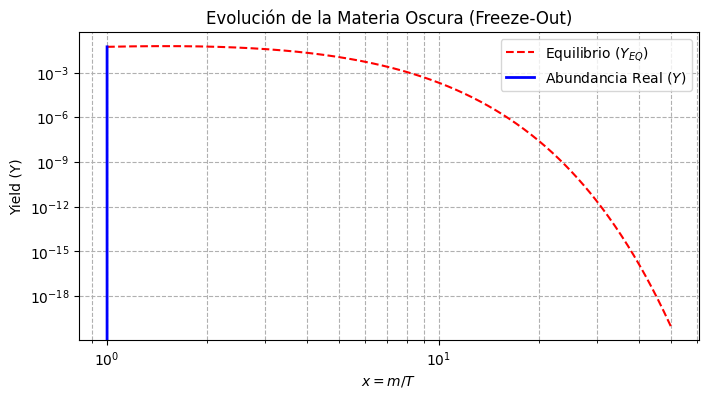

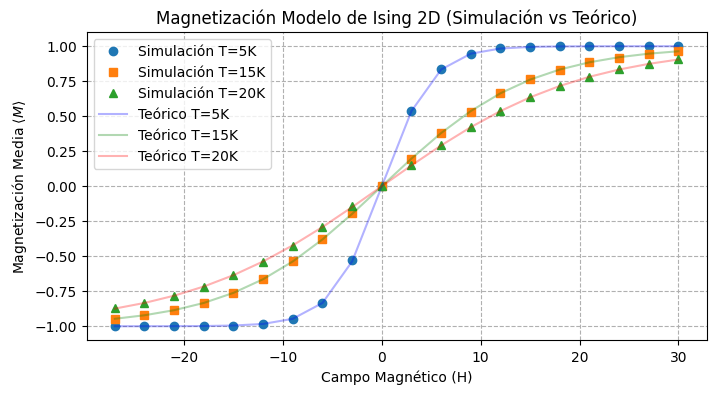

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# GRAFICA: Ecuación de Boltzmann (Materia Oscura)
try:
    data_dm = np.loadtxt("boltzmann_yield.txt", skiprows=1)
    x = data_dm[:, 0]
    Y = data_dm[:, 1]
    Y_EQ = data_dm[:, 2]

    plt.figure(figsize=(8, 4))
    plt.plot(x, Y_EQ, 'r--', label=r'Equilibrio ($Y_{EQ}$)')
    plt.plot(x, Y, 'b-', lw=2, label=r'Abundancia Real ($Y$)')
    plt.yscale('log')
    plt.xscale('log')
    plt.title("Evolución de la Materia Oscura (Freeze-Out)")
    plt.xlabel("$x = m/T$")
    plt.ylabel("Yield (Y)")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()
except Exception as e:
    print("Error graficando Materia Oscura (¿ejecutaste ./boltzmann?):", e)

#  GRAFICA: Modelo de Ising
try:
    data_ising = np.loadtxt("ising_magnetizacion.txt", skiprows=1)
    H = data_ising[:, 0]

    plt.figure(figsize=(8, 4))
    # Graficamos la simulación (puntos)
    plt.plot(H, data_ising[:,1], 'o', label='Simulación T=5K')
    plt.plot(H, data_ising[:,2], 's', label='Simulación T=15K')
    plt.plot(H, data_ising[:,3], '^', label='Simulación T=20K')

    # Graficamos la solución analítica (líneas continuas para comparar)
    plt.plot(H, np.tanh(H/5.0), 'b-', alpha=0.3, label='Teórico T=5K')
    plt.plot(H, np.tanh(H/15.0), 'g-', alpha=0.3, label='Teórico T=15K')
    plt.plot(H, np.tanh(H/20.0), 'r-', alpha=0.3, label='Teórico T=20K')

    plt.title("Magnetización Modelo de Ising 2D (Simulación vs Teórico)")
    plt.xlabel("Campo Magnético (H)")
    plt.ylabel(r"Magnetización Media $\langle M \rangle$")
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()
except Exception as e:
    print("Error graficando Ising (¿ejecutaste ./ising?):", e)



 El resultado analítico esperado para un conjunto de espines no interactuantes inmersos en un baño térmico y un campo exterior $H$ sigue la distribución de Maxwell-Boltzmann de un sistema de dos niveles, lo cual nos da exactamente la función tangente hiperbólica:


$$\langle M \rangle = \tanh\left(\frac{H}{T}\right)$$


Al ejecutar el código de C++ y graficar  con Python se ve que los puntos del algoritmo de Monte Carlo (C++) se superponen  sobre la curva teórica (Python).En esta implementación no hay interacción entre partículas ($J=0$)